# Decoded Plots

In [1]:
import sys
import importlib
import pandas as pd
from pathlib import Path

repo_src = None
repo_root = None
for base in [Path.cwd(), *Path.cwd().parents]:
    if (base / "src" / "plots" / "plot_helpers.py").exists():
        repo_src = base / "src" / "plots"
        repo_root = base
        break
    if (base / "plots" / "plot_helpers.py").exists():
        repo_src = base / "plots"
        repo_root = base.parent
        break
    if (base / "plot_helpers.py").exists():
        repo_src = base
        repo_root = base.parent.parent
        break

if repo_src is None or repo_root is None:
    raise FileNotFoundError("Could not locate plot_helpers.py")

if str(repo_src) not in sys.path:
    sys.path.insert(0, str(repo_src))

import plot_helpers

importlib.reload(plot_helpers)

paths = {
    "decoded": repo_root / "output" / "decoded.csv",
    "decoded_bpsk": repo_root / "output" / "decoded_bpsk.csv",
    "decoded_no_wa": repo_root / "output" / "encode_decode_no_wa.csv",
    "decoded_no_wa_bpsk": repo_root / "output" / "encode_decode_no_wa_bpsk.csv",
    "decoded_no_wa_backup": repo_root / "output" / "encode_decode_no_wa.csv.bak",
    "without_end_preamble": repo_root
    / "output"
    / "encode_decode_no_wa_no_end_preamble.csv",
}

df_first = pd.read_csv(
    paths["decoded"],
)
df_second = pd.read_csv(
    paths["decoded_bpsk"],
)

LABEL_FIRST: str = "dbpsk with WhatsApp"
LABEL_SECOND: str = "bspk with WhatsApp"

# Comparison between DBPSK and BPSK
From this comparison we can analyze what actually gets recognized in the file: is the preamble recognized? Is the decoded payload long enough?
These are the possible errors:
* `not-valid-preamble`: the preamble has not been recognized
* `check-error`: safety guards on the waveform properties
* `no-length-in-header`: the header is shorter than 16 bits, which are used to represent the number of bytes of the payload
* `paylod-too-short`: the payload is shorter than the number of bytes that are in the header

If there is no error, the status is `valid-preamble`.

In [2]:
from plot_helpers import print_decode_status, print_error_comparison

print(f"{LABEL_FIRST}:")
print_decode_status(df_first)
print()
print(f"{LABEL_SECOND}:")
print_decode_status(df_second)
print()
print_error_comparison(
    df_first,
    df_second,
    LABEL_FIRST,
    LABEL_SECOND,
)

dbpsk with WhatsApp:
valid preambles: 299
not valid: 120
errors: 81
types of error: ['paylod-too-short']

bspk with WhatsApp:
valid preambles: 288
not valid: 125
errors: 87
types of error: ['paylod-too-short']

Mean error dbpsk with WhatsApp: 0.7471
Mean error bspk with WhatsApp: 0.8027
Variance error dbpsk with WhatsApp: 0.132
Variance error bspk with WhatsApp: 0.1096

dbpsk with WhatsApp is better than bspk with WhatsApp: 206, 41.2%
dbpsk with WhatsApp is equal to bspk with WhatsApp: 128, 25.6%
dbpsk with WhatsApp is worse than bspk with WhatsApp: 166, 33.2%
Mean improvement: -0.4418
Improvement variance: 0.1285
Mean worsening: 0.381
Worsening variance: 0.129


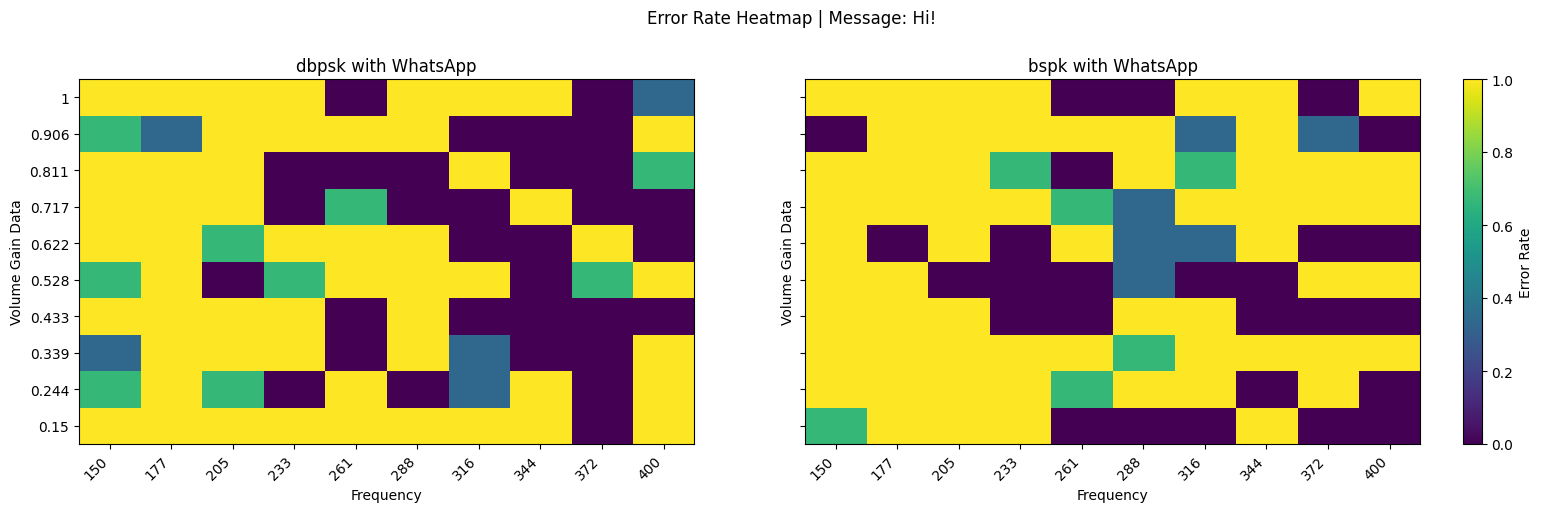

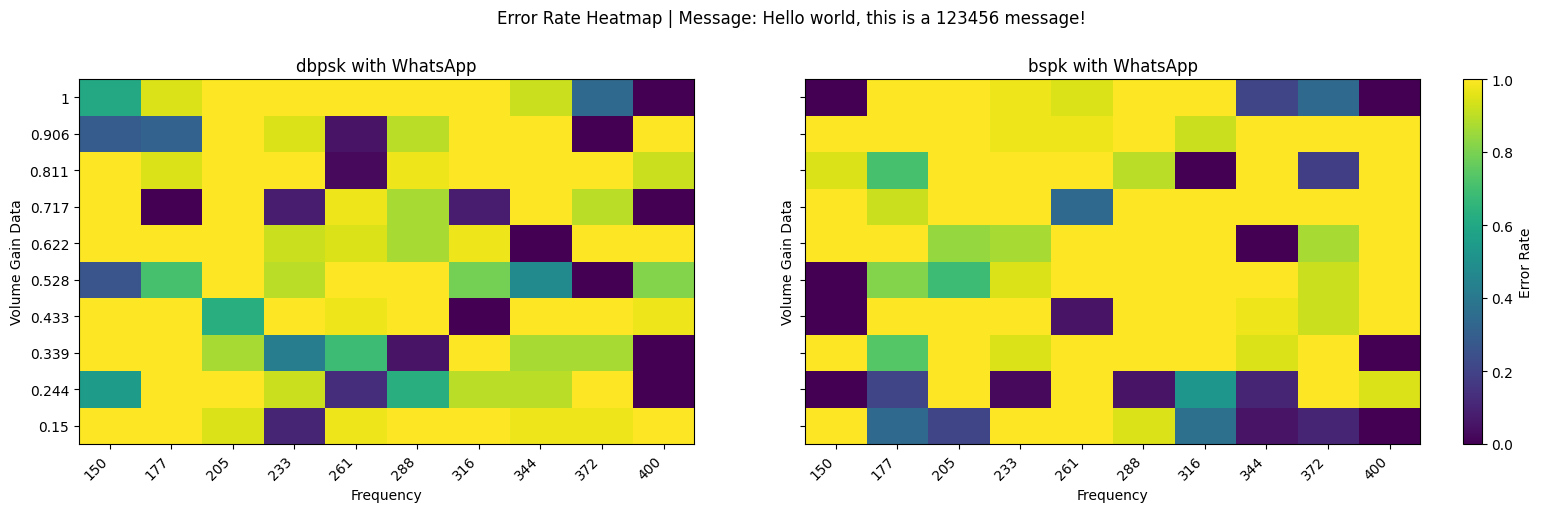

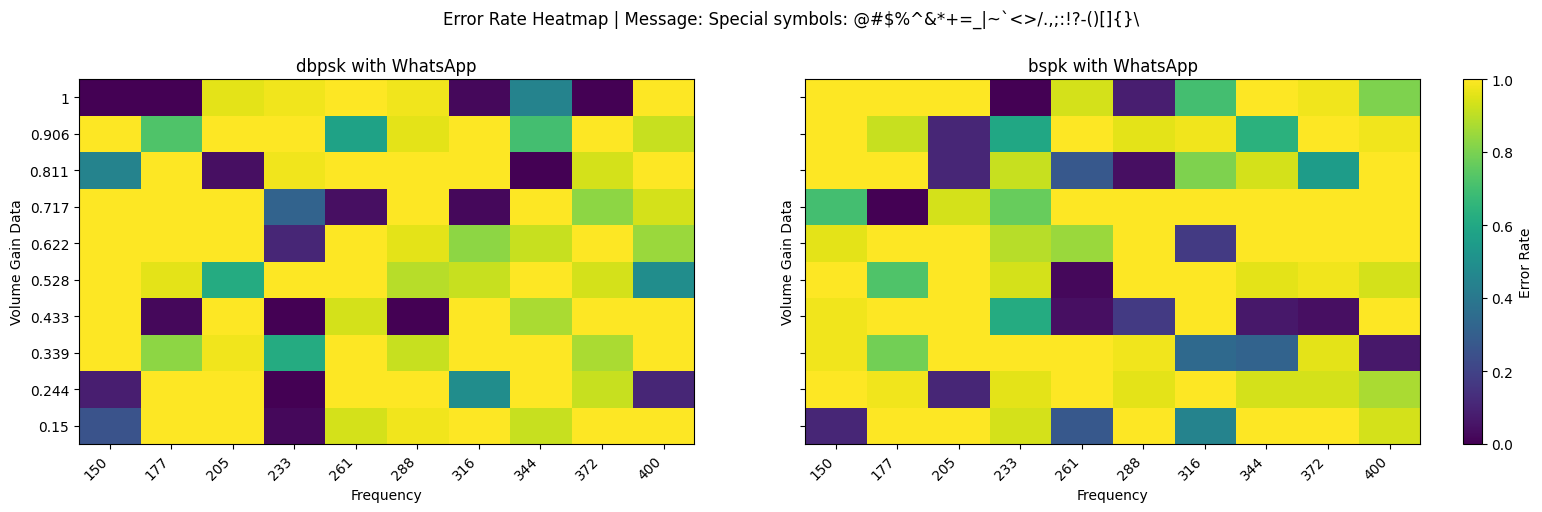

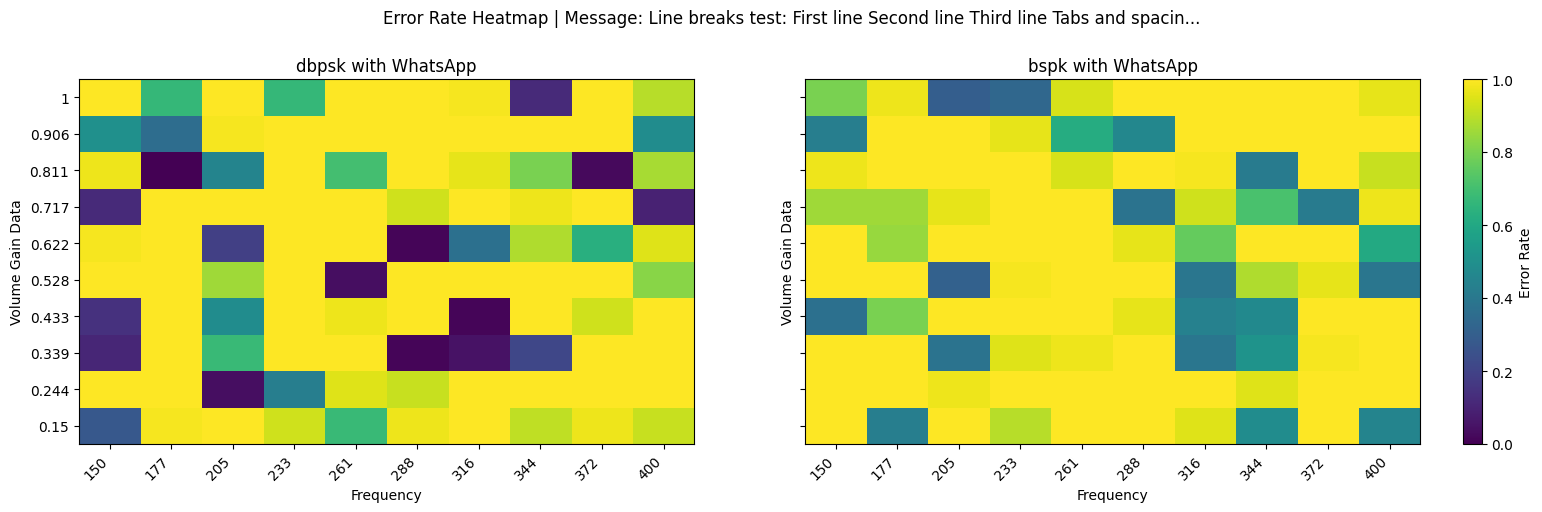

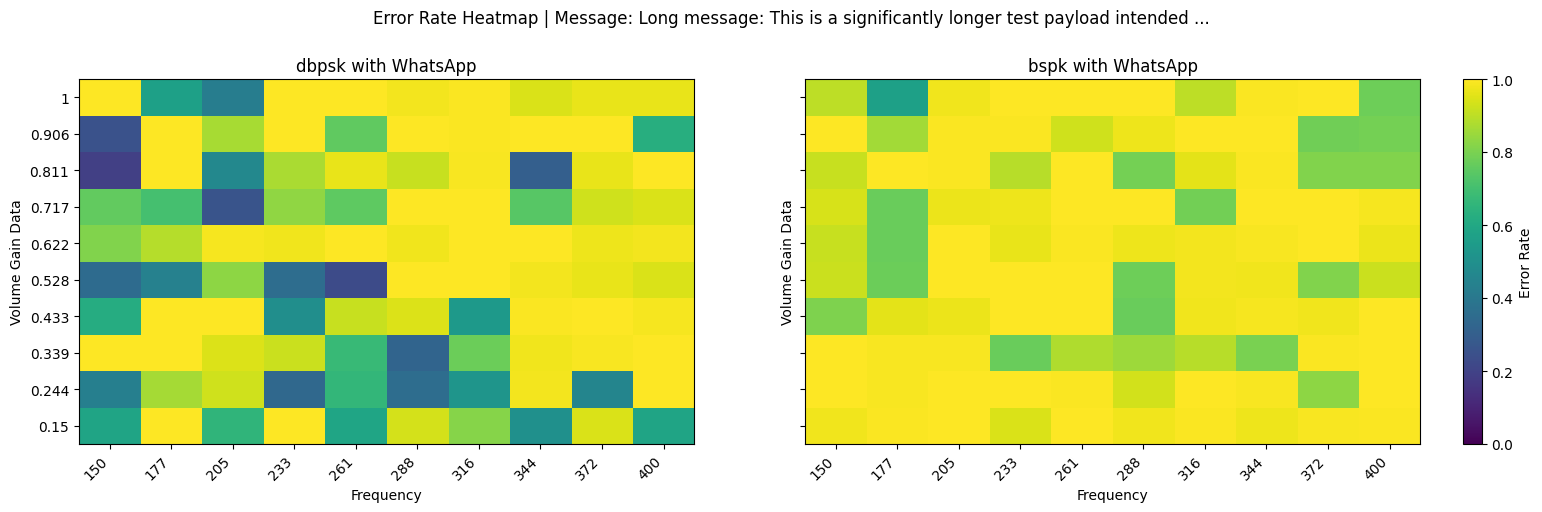

In [3]:
from plot_helpers import plot_error_rate_heatmaps_by_message_comparison

plot_error_rate_heatmaps_by_message_comparison(
    df_first,
    df_second,
    label_a=LABEL_FIRST,
    label_b=LABEL_SECOND,
)

## Error Rate vs Frequency (Comparison per Message)
Each figure is split into two columns for direct comparison between actual and best-case runs.

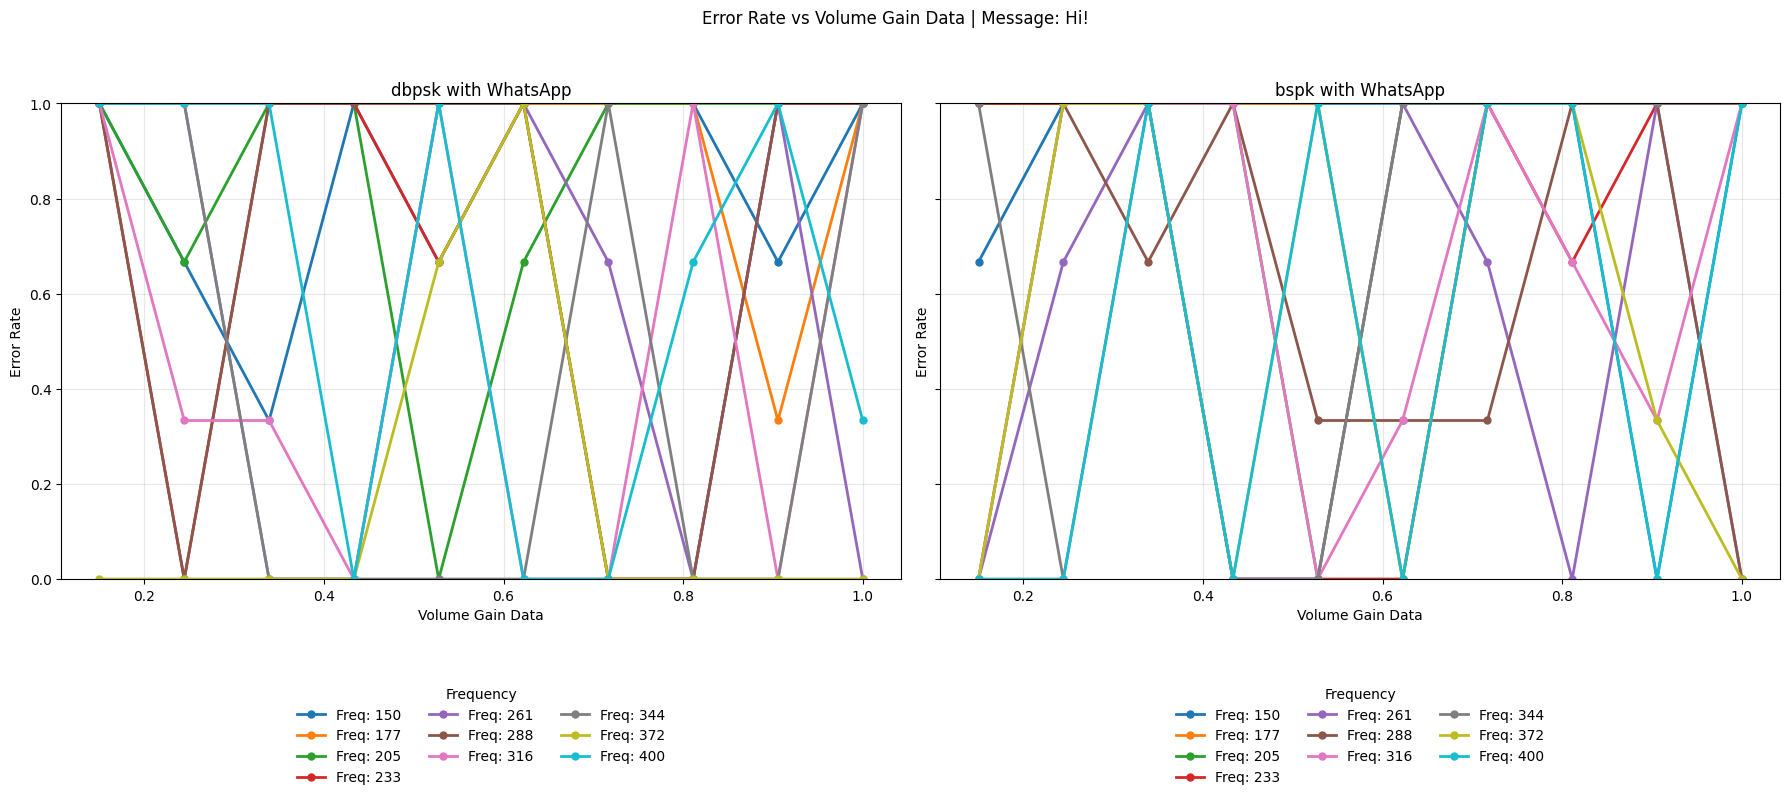

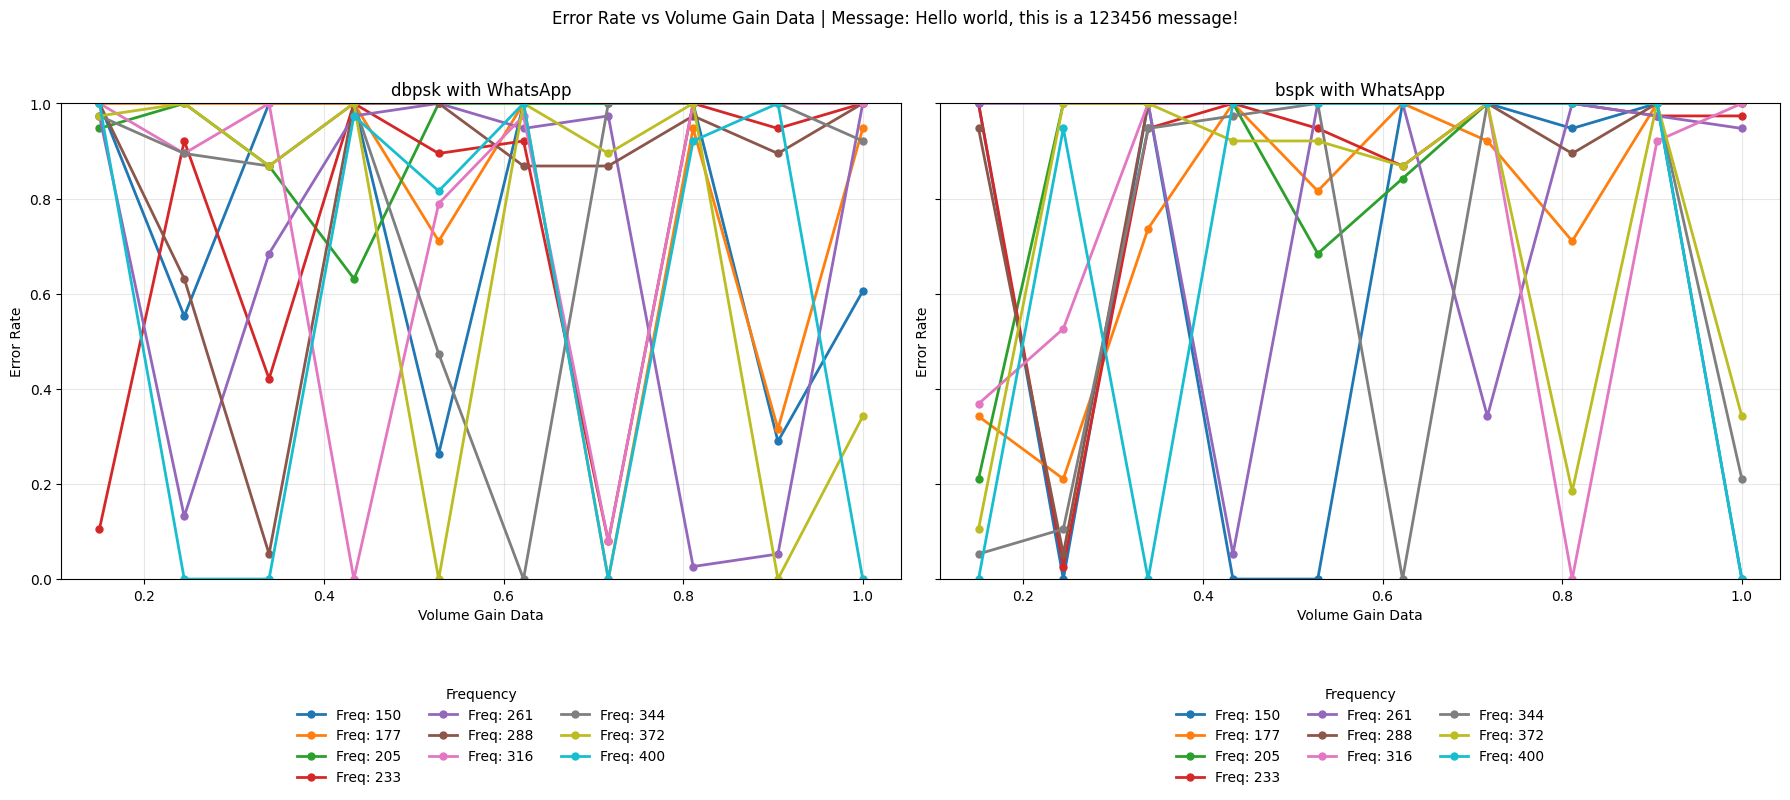

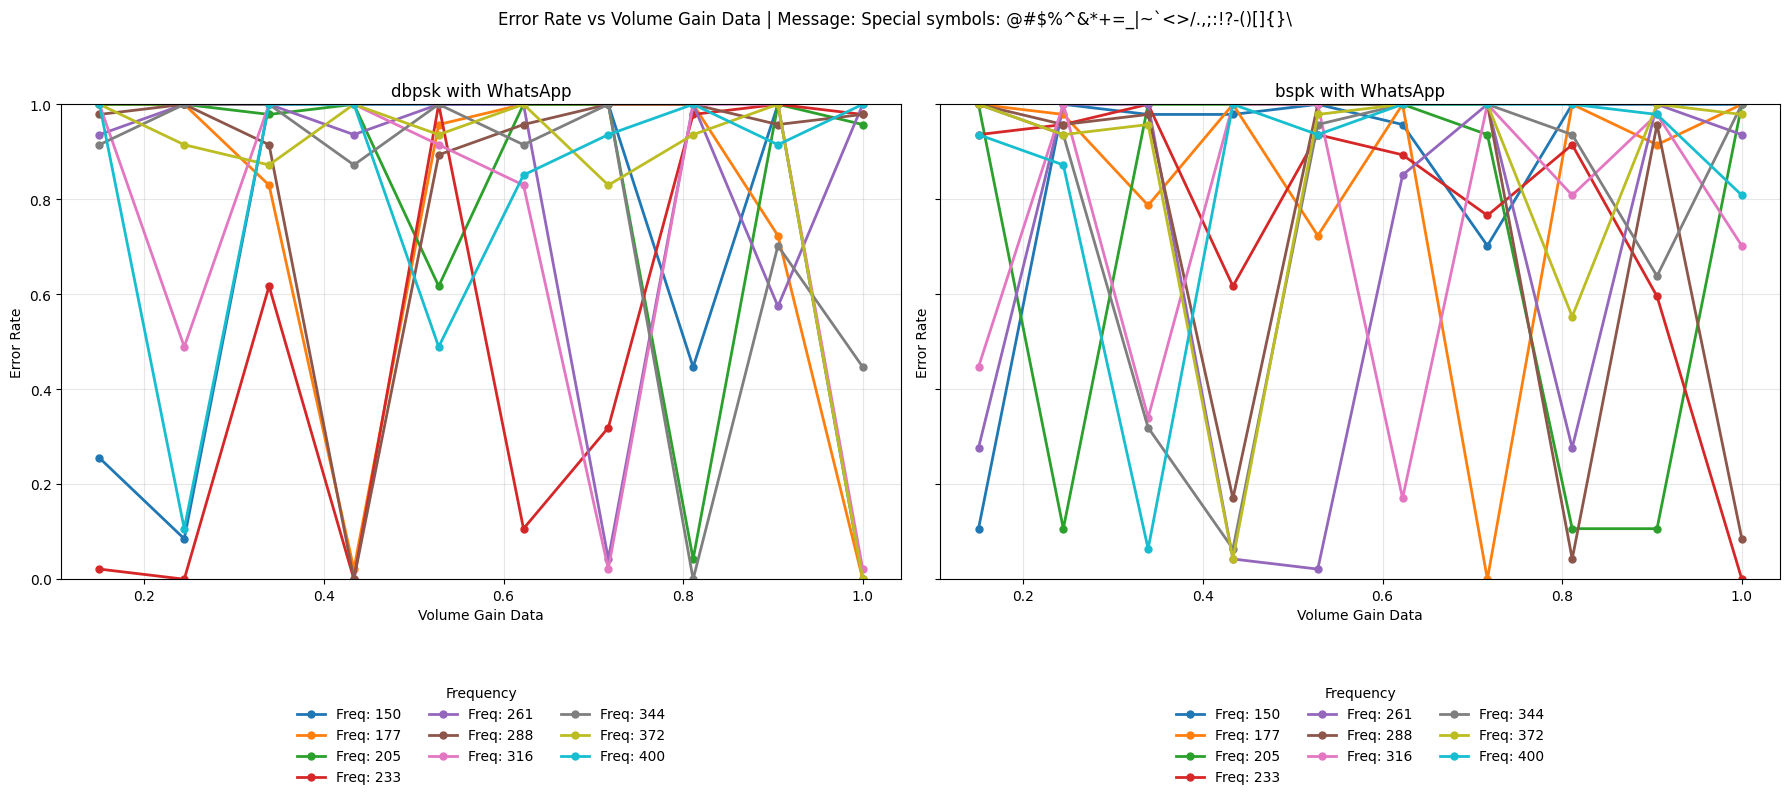

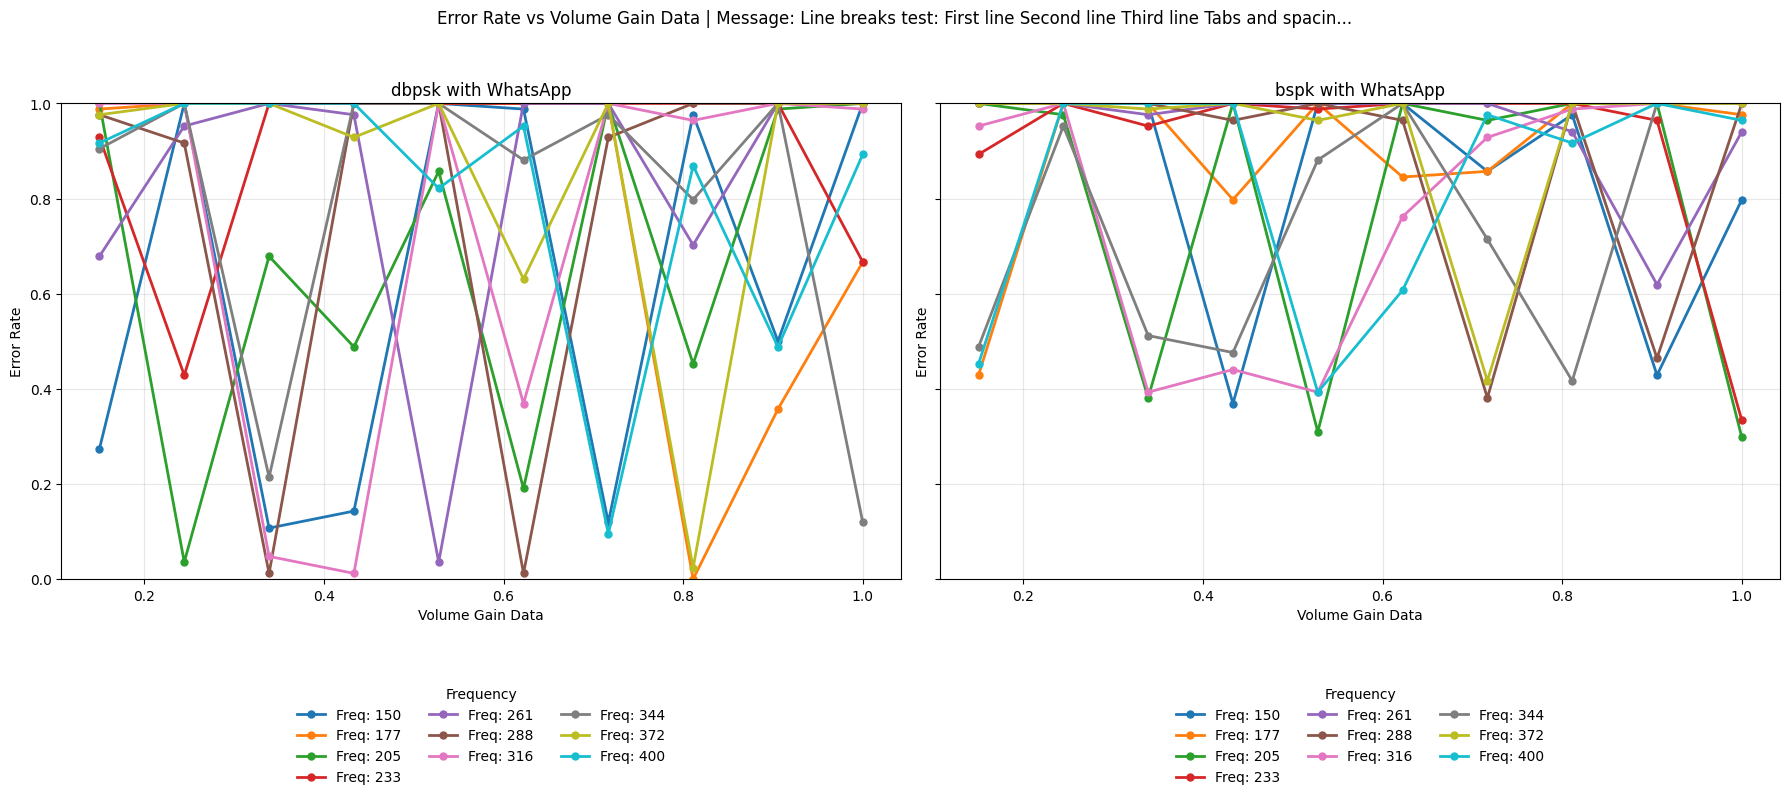

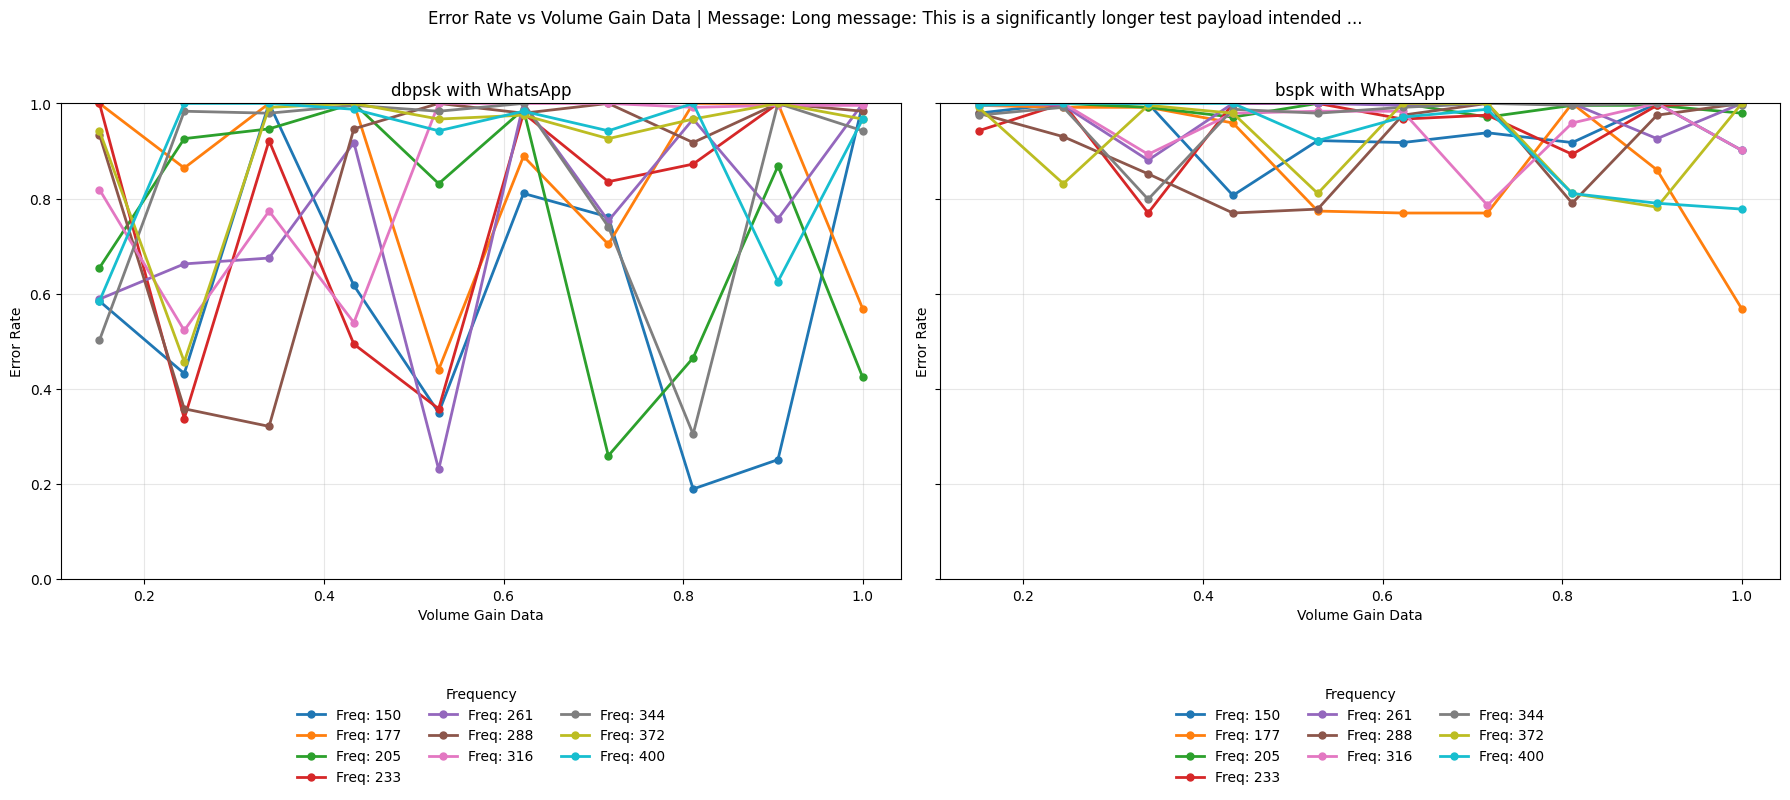

In [4]:
from plot_helpers import plot_error_rate_vs_frequency_by_message_comparison

plot_error_rate_vs_frequency_by_message_comparison(
    df_first,
    df_second,
    label_a=LABEL_FIRST,
    label_b=LABEL_SECOND,
)

## Error Rate Variance by Frequency (All Volume Gain Data Values, Comparison)
This section generates one comparison figure per available `volume_gain_data` value.
Each figure has:
- Column A: `csv_path`
- Column B: `no_audio_compression`
Violin plots are used by default and automatically fall back to box plots when groups are sparse.

Generating 10 comparison plots (one per volume_gain_data).


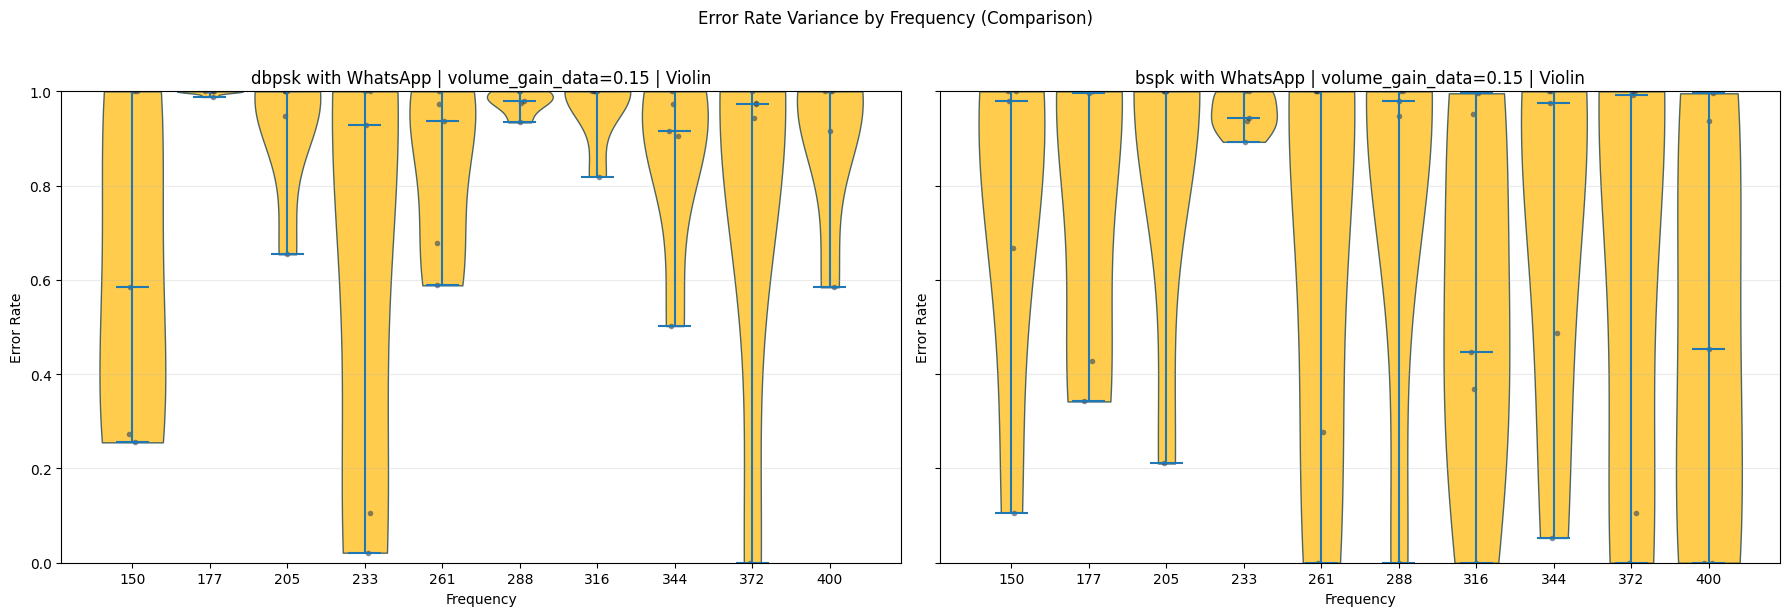

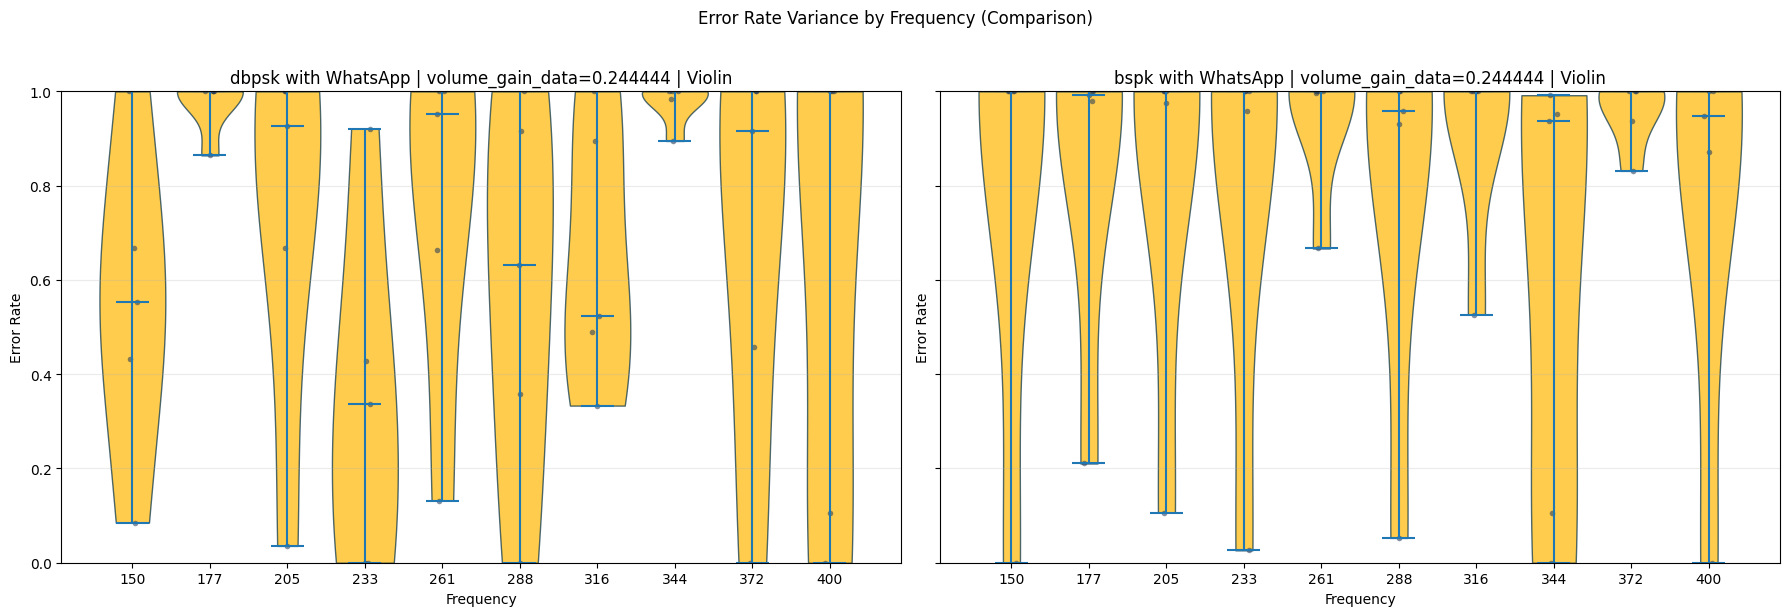

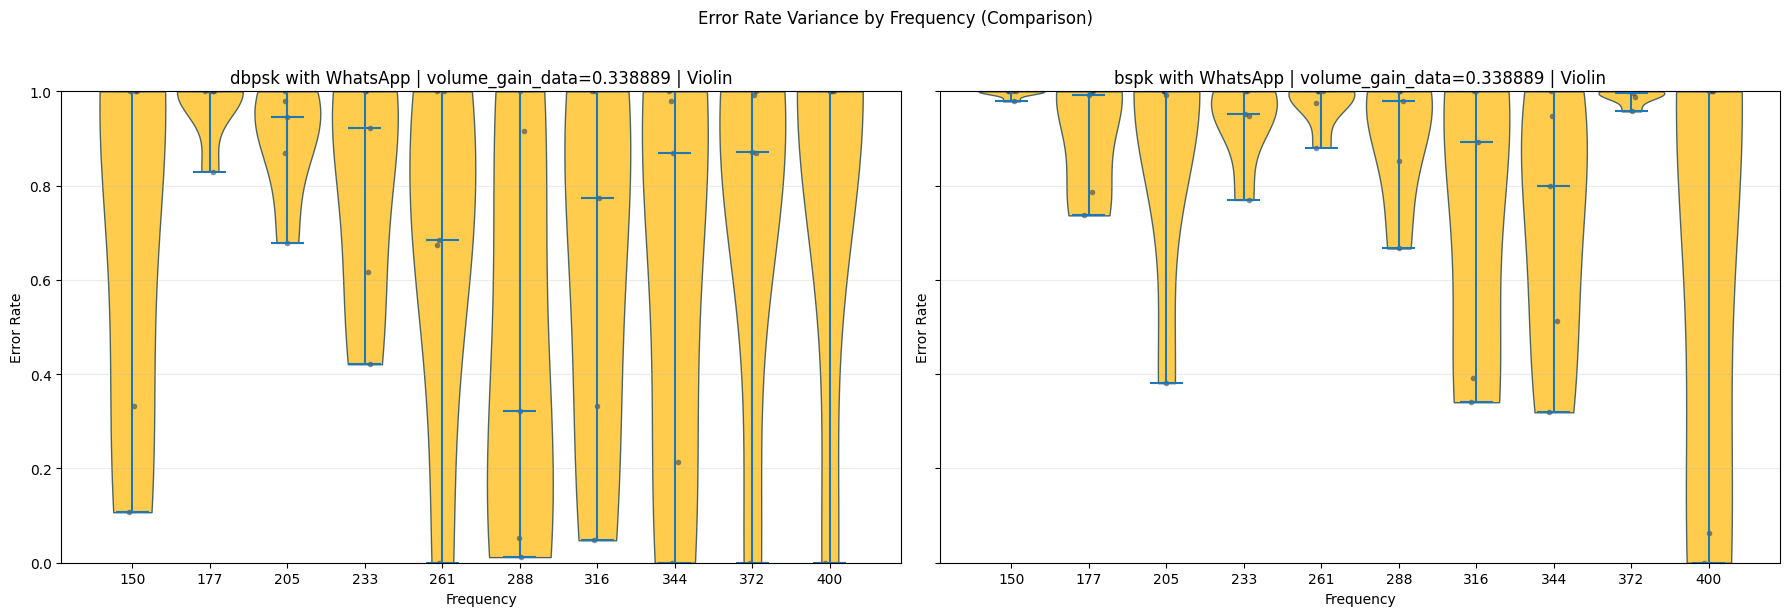

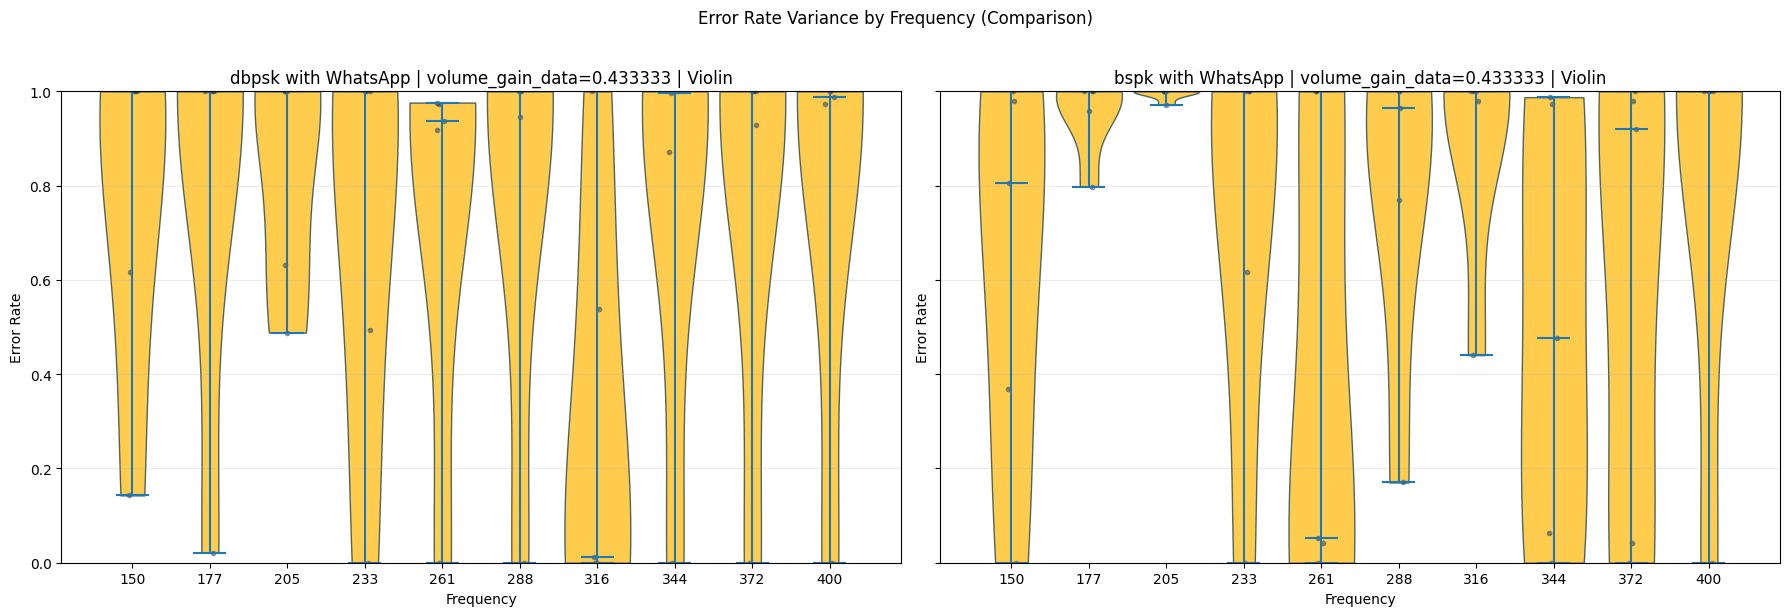

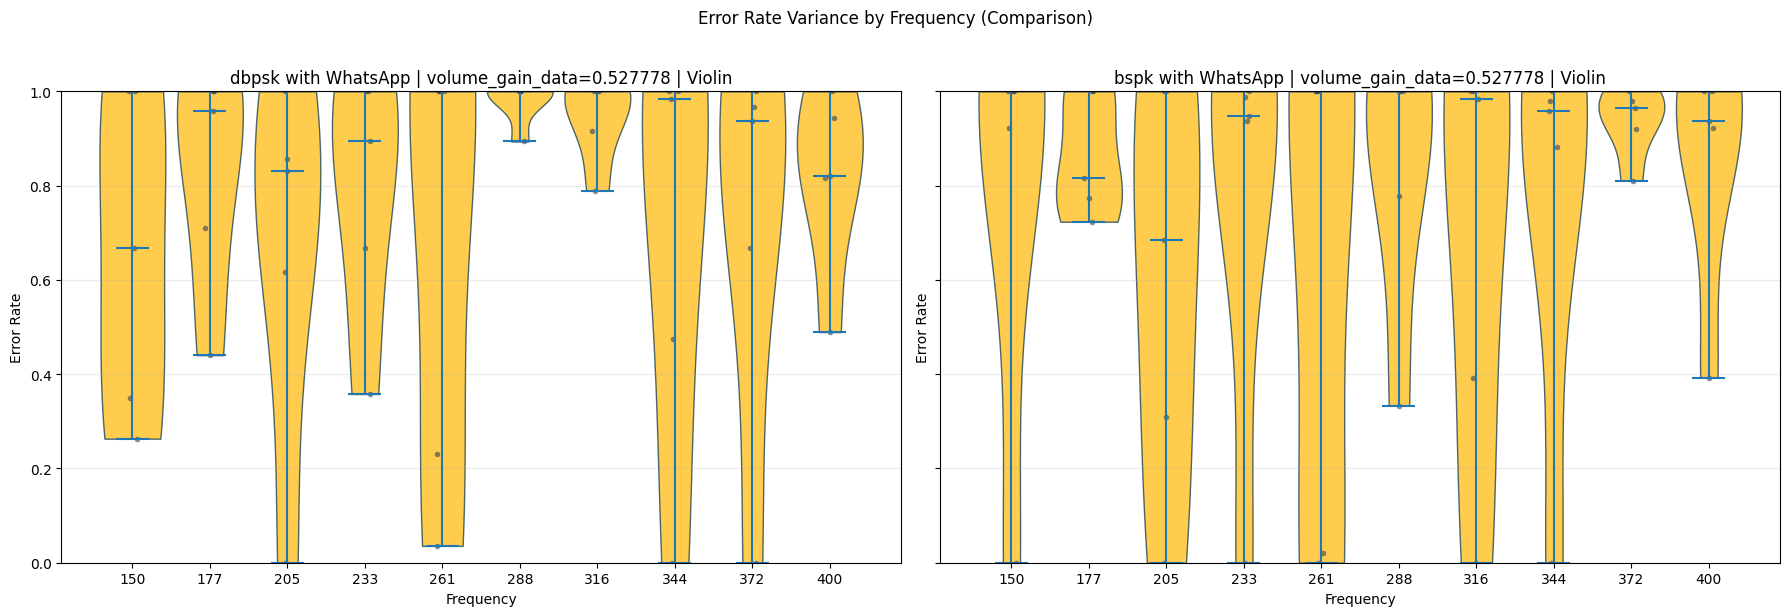

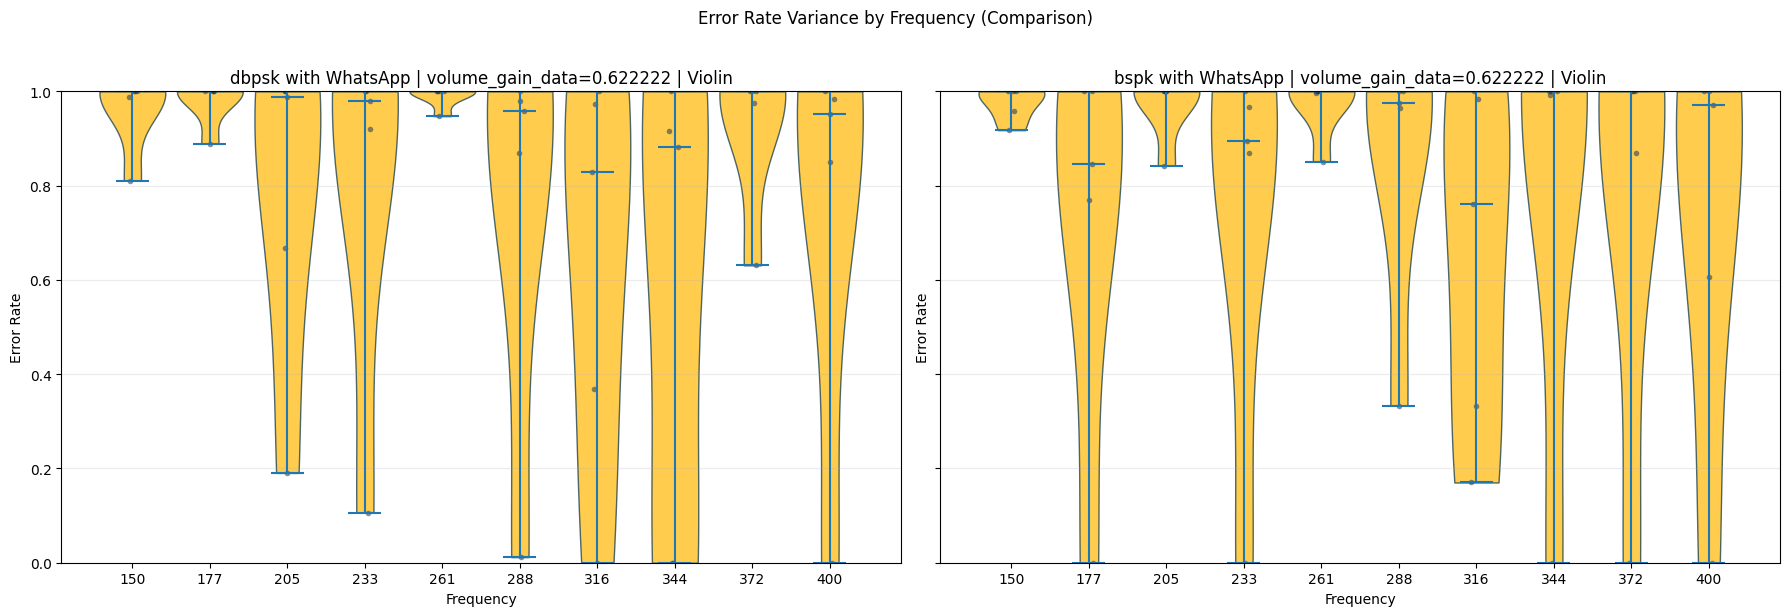

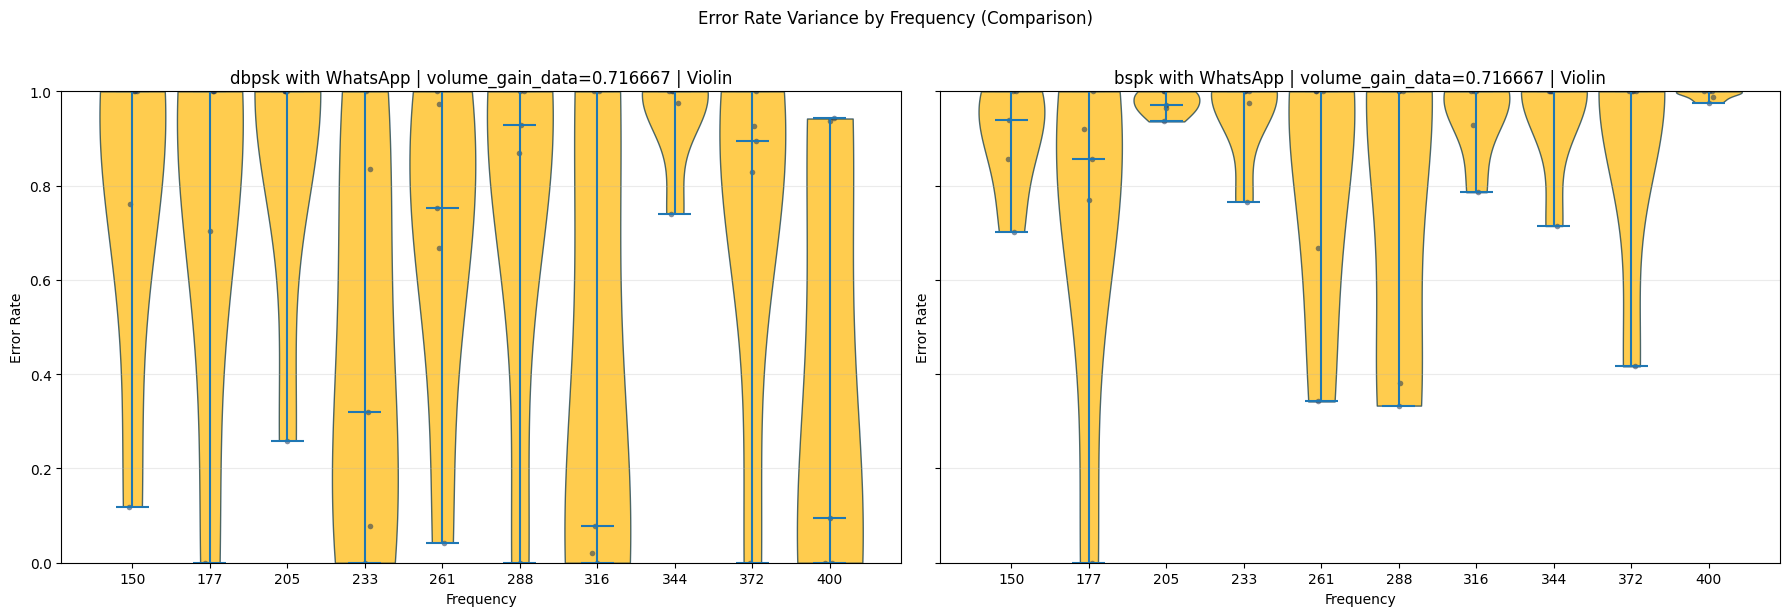

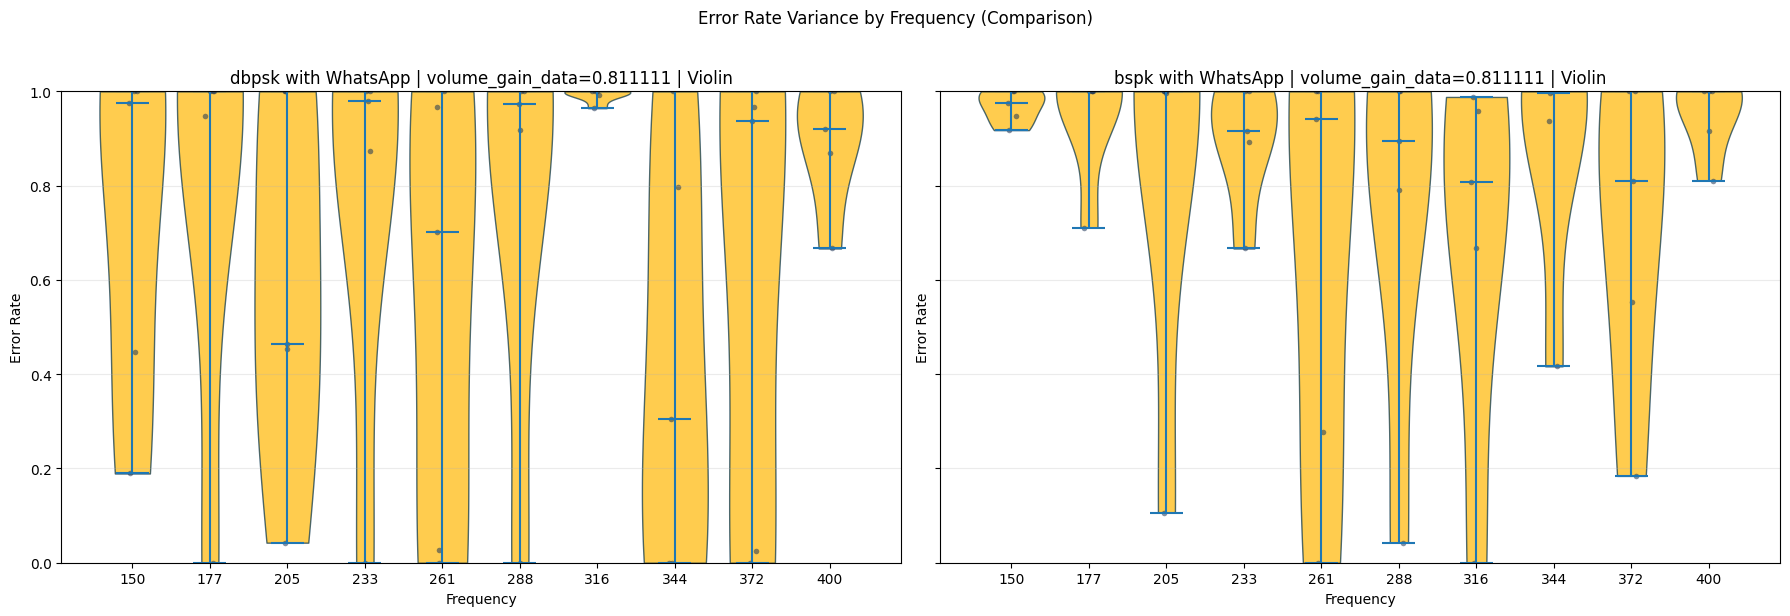

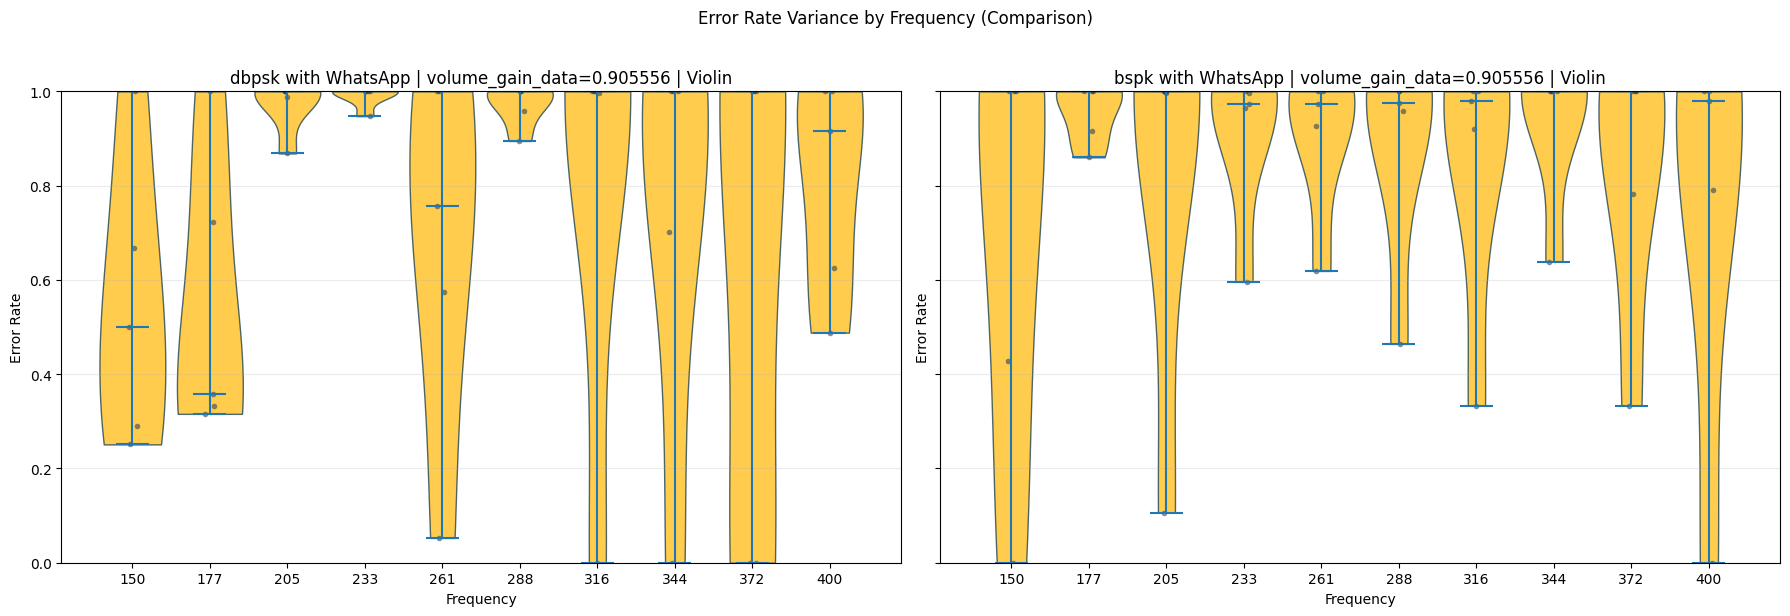

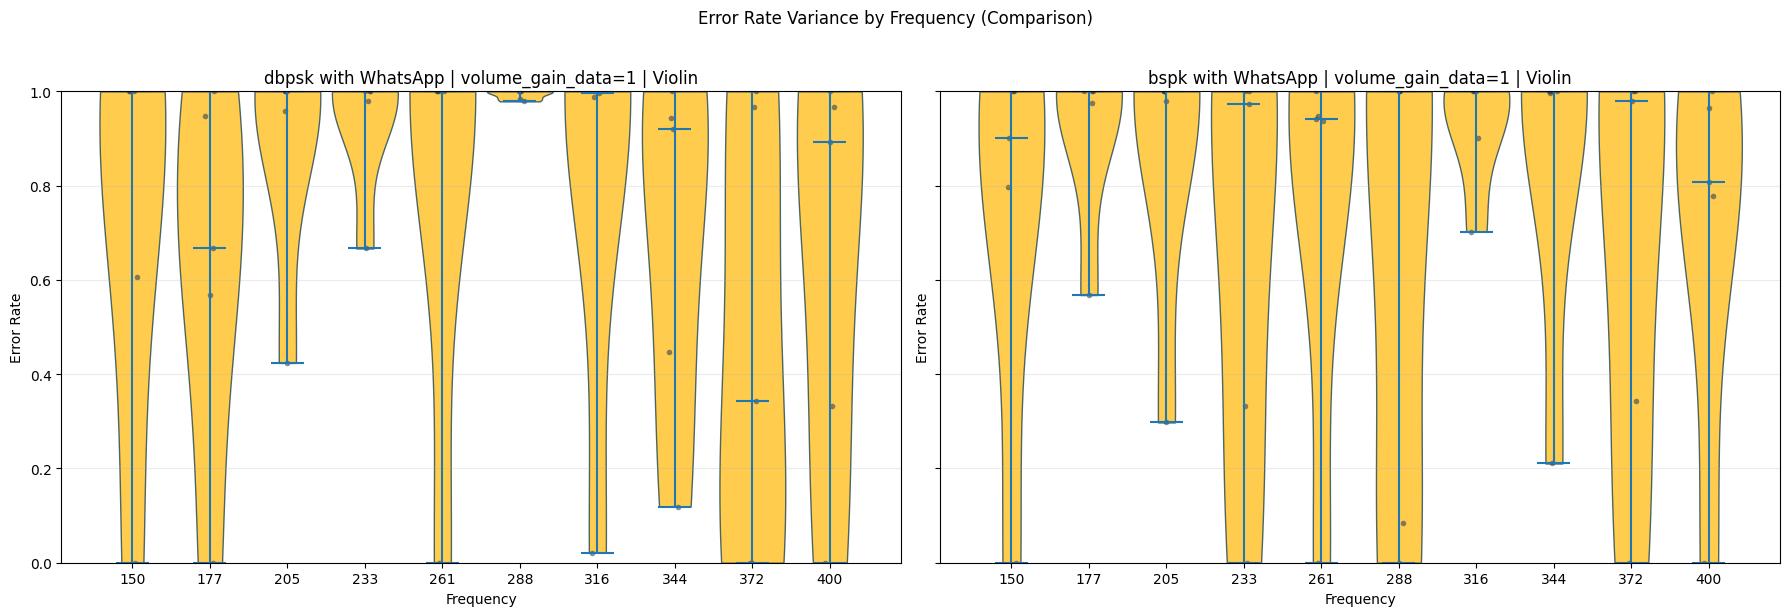

In [5]:
from plot_helpers import plot_error_rate_variance_for_all_volume_gains_comparison

plot_error_rate_variance_for_all_volume_gains_comparison(
    df_first,
    df_second,
    label_a=LABEL_FIRST,
    label_b=LABEL_SECOND,
    prefer_box_if_sparse=True,
    min_points_per_group=5,
)

## 3D Static Render (Non-interactive)
This adds a static 3D view of the same comparison data without changing the interactive Plotly figure above.

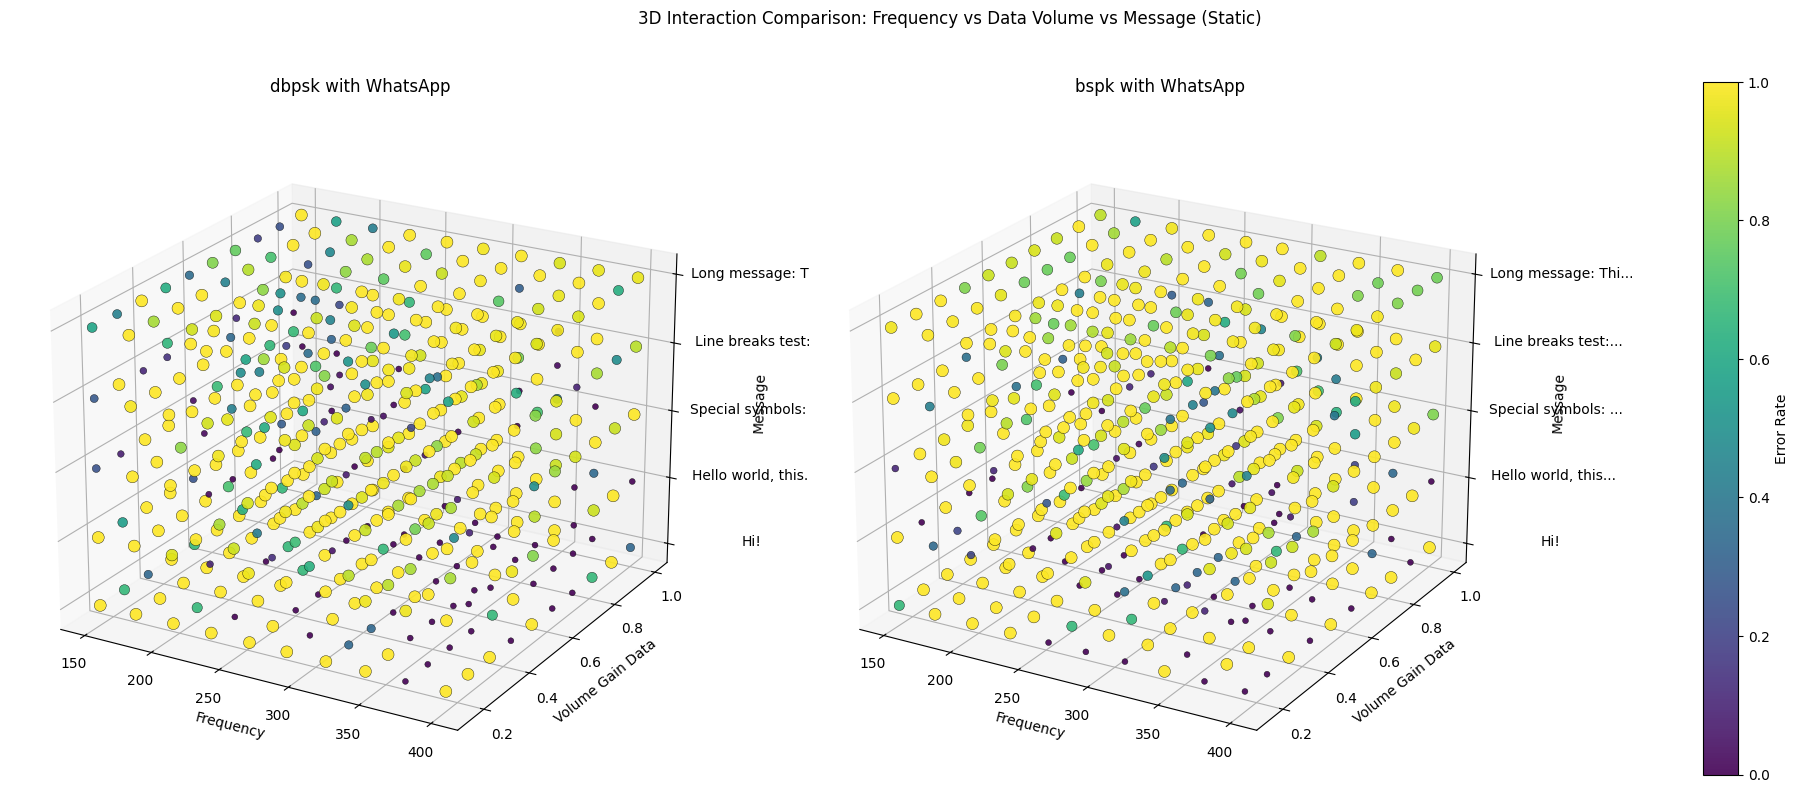

In [6]:
from plot_helpers import plot_static_3d_interaction_comparison

plot_static_3d_interaction_comparison(
    df_first,
    df_second,
    label_a=LABEL_FIRST,
    label_b=LABEL_SECOND,
)

## 3D Interaction: Frequency, Data Volume, and Message (Comparison)
This figure is split into two 3D panels:
- Column A: `csv_path` (actual pipeline output)
- Column B: `no_audio_compression` (best-case reference)
Color and marker size encode `error_rate` (lower is better).

In [7]:
from plot_helpers import plot_3d_interaction_comparison

plot_3d_interaction_comparison(
    df_first,
    df_second,
    label_a=LABEL_FIRST,
    label_b=LABEL_SECOND,
)